<a href="https://colab.research.google.com/github/Jaideep3020/HDFC_ALGORITHM/blob/main/UNSUPERVISED%20SEMATIC%20SEGMENTATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir src notebooks data outputs

In [ ]:
ls

 data/             outputs/   'UNSUPERVISED SEMATIC SEGMENTATION.ipynb'
 experiments.csv   README.md
 notebooks/        src/


In [ ]:
!pip install pydicom -qq

import os
import cv2
import pydicom
import numpy as np
import torch
import timm
import torchvision.transforms as T
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
from scipy import ndimage
from scipy.optimize import linear_sum_assignment

print("✅ All libraries imported")
print(f"PyTorch version : {torch.__version__}")

✅ All libraries imported
PyTorch version : 2.10.0+cu128


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from google.colab import drive
# Check if drive is already mounted to avoid redundant mounting attempts
if not os.path.exists('/content/drive/MyDrive'):
  drive.mount('/content/drive')
else:
  print('Google Drive is already mounted.')

# Then, verify the path to your dataset. You can list contents of your drive:
# !ls "/content/drive/MyDrive/archive/"

CT_DIR  = "/content/drive/MyDrive/archive/CHAOS_Train_Sets/Train_Sets/CT"
MRI_DIR = "/content/drive/MyDrive/archive/CHAOS_Train_Sets/Train_Sets/MR"

# ── Filter Mac system files ──
ct_patients  = sorted([
    p for p in os.listdir(CT_DIR)
    if not p.startswith('.')
    and os.path.isdir(os.path.join(CT_DIR, p))
])
mri_patients = sorted([
    p for p in os.listdir(MRI_DIR)
    if not p.startswith('.')
    and os.path.isdir(os.path.join(MRI_DIR, p))
])

print(f"CT  patients : {len(ct_patients)} → {ct_patients}")
print(f"MRI patients : {len(mri_patients)} → {mri_patients}")

Google Drive is already mounted.
CT  patients : 20 → ['1', '10', '14', '16', '18', '19', '2', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '5', '6', '8']
MRI patients : 20 → ['1', '10', '13', '15', '19', '2', '20', '21', '22', '3', '31', '32', '33', '34', '36', '37', '38', '39', '5', '8']


In [ ]:
device = torch.device('cuda')

model = timm.create_model(
    'vit_small_patch8_224.dino',
    pretrained=True,
    num_classes=0
)
for param in model.parameters():
    param.requires_grad = False
model.eval().to(device)

print(f"Device           : {device}")
print(f"Model            : DINO ViT-S/8")
print(f"Parameters frozen: {all(not p.requires_grad for p in model.parameters())}")
print(f"Number of blocks : {len(model.blocks)}")

Device           : cuda
Model            : DINO ViT-S/8
Parameters frozen: True
Number of blocks : 12


In [ ]:
def load_and_preprocess_ct(dcm_path):
    """
    Loads CT DICOM file.
    Applies RescaleIntercept, HU windowing,
    normalization, resize, RGB conversion.
    """
    dcm       = pydicom.dcmread(dcm_path)
    intercept = getattr(dcm, 'RescaleIntercept', 0)
    slope     = getattr(dcm, 'RescaleSlope', 1)
    slc       = dcm.pixel_array.astype(np.int32)
    slc       = slc * int(slope) + int(intercept)
    slc       = np.clip(slc, -150, 250)
    slc       = (slc - (-150)) / (250 - (-150))
    slc       = slc.astype(np.float32)
    slc       = cv2.resize(slc, (224, 224),
                           interpolation=cv2.INTER_LINEAR)
    return np.stack([slc, slc, slc], axis=-1)

def load_and_preprocess_mri(dcm_path):
    """
    Loads MRI DICOM file.
    Applies min-max normalization,
    resize, RGB conversion.
    """
    dcm = pydicom.dcmread(dcm_path)
    slc = dcm.pixel_array.astype(np.float32)
    slc -= slc.min()
    if slc.max() != 0:
        slc /= slc.max()
    slc = cv2.resize(slc, (224, 224),
                     interpolation=cv2.INTER_LINEAR)
    return np.stack([slc, slc, slc], axis=-1)

def is_informative(slice_2d, threshold=0.02):
    """Filters empty/background-only slices."""
    return np.sum(slice_2d > 0.05) / slice_2d.size \
           > threshold

def select_abdominal_slices(volume, start=0.3, end=0.7):
    """Selects middle 40% of slices — abdominal region."""
    total     = volume.shape[0]
    start_idx = int(total * start)
    end_idx   = int(total * end)
    return volume[start_idx:end_idx], start_idx, end_idx

def load_gt_mask(mask_path):
    """Loads ground truth mask and resizes to 224x224."""
    if mask_path.endswith('.png'):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    else:
        mask = pydicom.dcmread(mask_path).pixel_array
    return cv2.resize(
        mask.astype(np.float32), (224, 224),
        interpolation=cv2.INTER_NEAREST
    ).astype(np.uint8)

print("✅ Preprocessing functions loaded")

✅ Preprocessing functions loaded


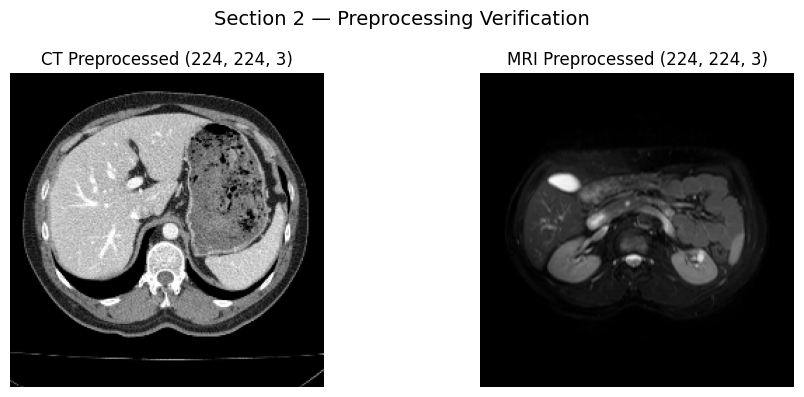

CT  → shape: (224, 224, 3), range: [0.00, 1.00]
MRI → shape: (224, 224, 3), range: [0.00, 0.99]


In [ ]:
# ── Load and display sample CT + MRI slices ──
ct_dicom_dir  = os.path.join(CT_DIR,
                              ct_patients[0], 'DICOM_anon')
ct_files      = sorted([f for f in os.listdir(ct_dicom_dir)
                         if f.endswith('.dcm')])
ct_processed  = load_and_preprocess_ct(
    os.path.join(ct_dicom_dir, ct_files[40]))

mri_dicom_dir = os.path.join(MRI_DIR, mri_patients[0],
                              'T2SPIR', 'DICOM_anon')
mri_files     = sorted([f for f in os.listdir(mri_dicom_dir)
                         if f.endswith('.dcm')])
mri_processed = load_and_preprocess_mri(
    os.path.join(mri_dicom_dir, mri_files[18]))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(ct_processed)
axes[0].set_title(f'CT Preprocessed {ct_processed.shape}')
axes[0].axis('off')
axes[1].imshow(mri_processed)
axes[1].set_title(f'MRI Preprocessed {mri_processed.shape}')
axes[1].axis('off')
plt.suptitle('Section 2 — Preprocessing Verification',
             fontsize=14)
plt.tight_layout()
plt.show()

print(f"CT  → shape: {ct_processed.shape}, "
      f"range: [{ct_processed.min():.2f}, "
      f"{ct_processed.max():.2f}]")
print(f"MRI → shape: {mri_processed.shape}, "
      f"range: [{mri_processed.min():.2f}, "
      f"{mri_processed.max():.2f}]")

In [ ]:
def image_to_tensor(preprocessed_slice):
    """
    Converts preprocessed (224,224,3) array
    to normalized ImageNet tensor for DINO.
    """
    transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225])
    ])
    img_uint8 = (preprocessed_slice * 255).astype(np.uint8)
    return transform(
        Image.fromarray(img_uint8)
    ).unsqueeze(0).to(device)

def extract_hierarchical_features(img_tensor):
    """
    Extracts attention key features from
    last 3 transformer blocks of DINO.
    Returns: (784, 1152) feature tensor.
    """
    feat_out = {}
    def make_hook(name):
        def hook_fn(module, input, output):
            feat_out[name] = output
        return hook_fn

    num_blocks = len(model.blocks)
    hooks = []
    for layer_idx in [num_blocks-3,
                      num_blocks-2,
                      num_blocks-1]:
        h = model.blocks[layer_idx].register_forward_hook(
            make_hook(f'block_{layer_idx}'))
        hooks.append(h)

    with torch.no_grad():
        _ = model(img_tensor)

    for h in hooks:
        h.remove()

    features = []
    for key in sorted(feat_out.keys()):
        features.append(feat_out[key][0, 1:, :])

    return torch.cat(features, dim=-1).cpu().numpy()

print("✅ DINO feature extraction functions loaded")
print(f"Patch grid    : 28×28 = 784 patches")
print(f"Feature dim   : 384 × 3 blocks = 1152")

✅ DINO feature extraction functions loaded
Patch grid    : 28×28 = 784 patches
Feature dim   : 384 × 3 blocks = 1152


CT  feature shape : (784, 1152)
MRI feature shape : (784, 1152)


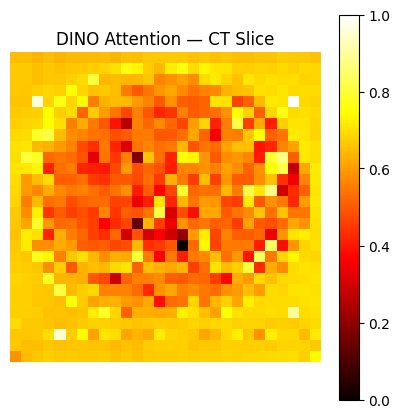

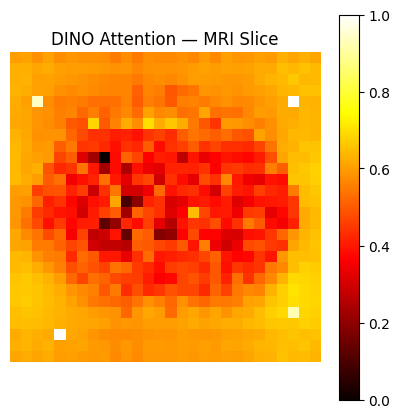

In [ ]:
def visualize_attention(K, title='Attention Map'):
    """Visualizes mean attention across feature dims."""
    h = w    = int(np.sqrt(K.shape[0]))
    attn_map = K.mean(axis=1).reshape(h, w)
    attn_map -= attn_map.min()
    attn_map /= attn_map.max()
    plt.figure(figsize=(5, 5))
    plt.imshow(attn_map, cmap='hot')
    plt.colorbar()
    plt.title(title)
    plt.axis('off')
    plt.show()

# ── Extract and visualize features ──
ct_tensor  = image_to_tensor(ct_processed)
K_ct       = extract_hierarchical_features(ct_tensor)

mri_tensor = image_to_tensor(mri_processed)
K_mri      = extract_hierarchical_features(mri_tensor)

print(f"CT  feature shape : {K_ct.shape}")
print(f"MRI feature shape : {K_mri.shape}")

visualize_attention(K_ct,  'DINO Attention — CT Slice')
visualize_attention(K_mri, 'DINO Attention — MRI Slice')

In [ ]:
def cluster_features_pca(K, n_clusters=5,
                          n_components=128,
                          random_state=42):
    """
    Normalizes → PCA → K-Means clustering.
    Returns cluster labels (784,).
    """
    scaler   = StandardScaler()
    K_scaled = scaler.fit_transform(K)
    pca      = PCA(n_components=n_components,
                   random_state=random_state)
    K_pca    = pca.fit_transform(K_scaled)
    print(f"  PCA variance explained : "
          f"{pca.explained_variance_ratio_.sum()*100:.1f}%")
    km = KMeans(n_clusters=n_clusters,
                random_state=random_state,
                n_init=20, max_iter=500)
    return km.fit_predict(K_pca)

def build_segmentation_map(labels, image_size=224):
    """Reshapes labels to patch grid and upsamples."""
    h = w        = int(np.sqrt(labels.shape[0]))
    label_grid   = labels.reshape(h, w)
    label_tensor = torch.tensor(
        label_grid, dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)
    seg_map = F.interpolate(
        label_tensor,
        size=(image_size, image_size),
        mode='nearest'
    ).squeeze().long().numpy()
    return seg_map

CLUSTER_COLORS = np.array([
    [0,   0,   0  ],
    [255, 0,   0  ],
    [0,   255, 0  ],
    [0,   0,   255],
    [255, 255, 0  ],
], dtype=np.uint8)

def colorize_segmentation(seg_map):
    return CLUSTER_COLORS[seg_map % 5]

print("✅ Clustering functions loaded")

✅ Clustering functions loaded


  PCA variance explained : 98.7%
  PCA variance explained : 99.2%


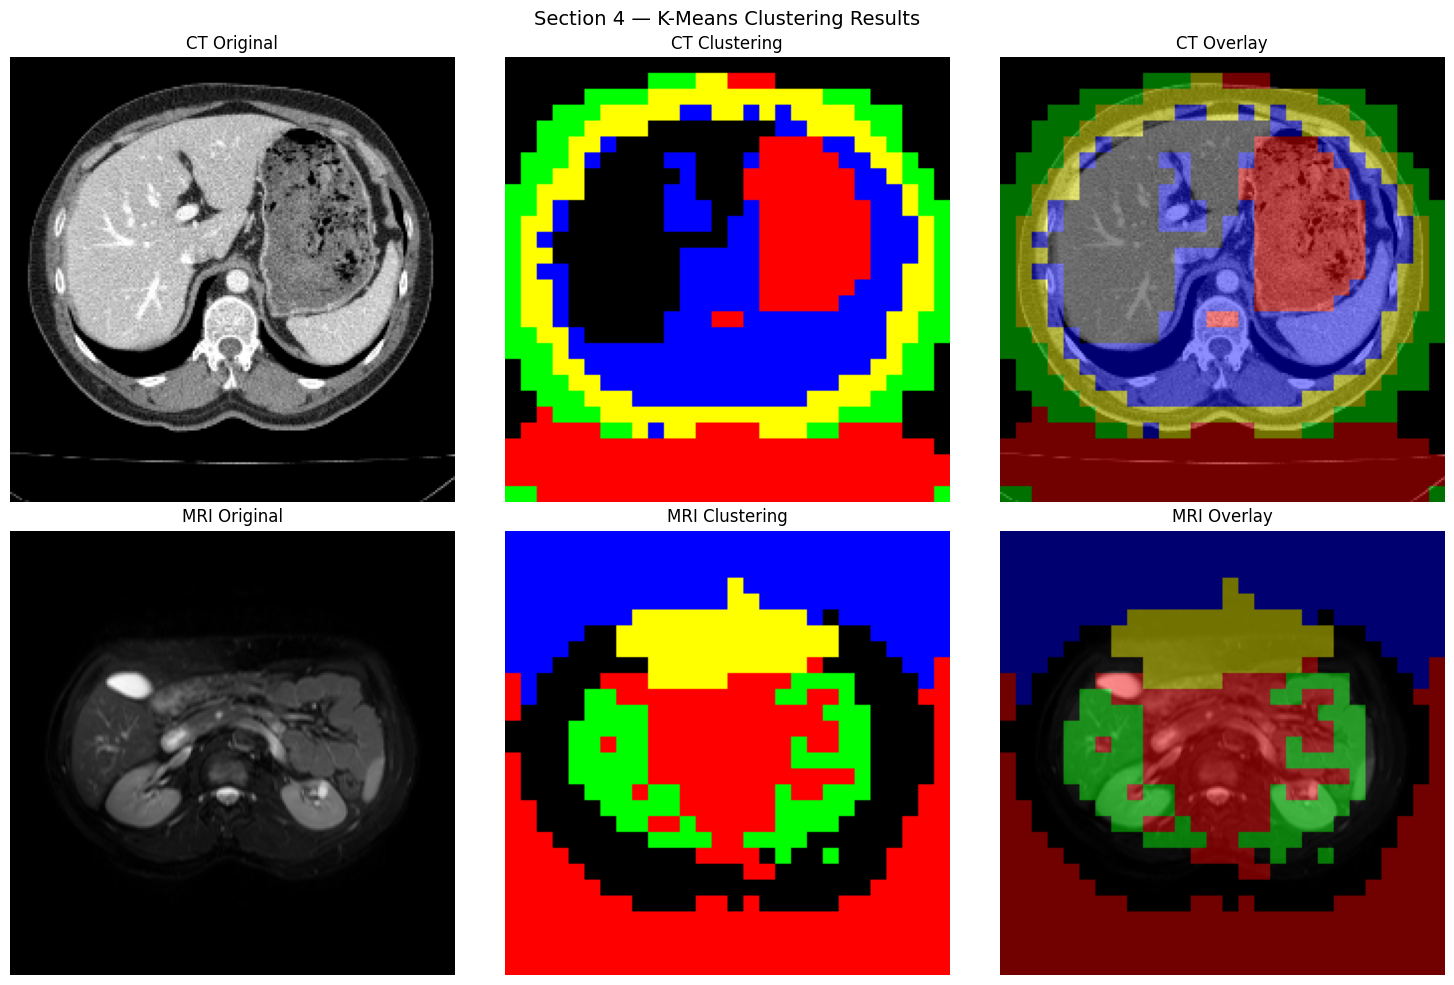

In [ ]:
# ── Cluster CT and MRI ──
labels_ct  = cluster_features_pca(K_ct,  n_clusters=7)
labels_mri = cluster_features_pca(K_mri, n_clusters=7)

seg_ct     = build_segmentation_map(labels_ct)
seg_mri    = build_segmentation_map(labels_mri)

fig, axes  = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(ct_processed)
axes[0,0].set_title('CT Original');       axes[0,0].axis('off')
axes[0,1].imshow(colorize_segmentation(seg_ct))
axes[0,1].set_title('CT Clustering');     axes[0,1].axis('off')
axes[0,2].imshow(ct_processed)
axes[0,2].imshow(colorize_segmentation(seg_ct), alpha=0.45)
axes[0,2].set_title('CT Overlay');        axes[0,2].axis('off')

axes[1,0].imshow(mri_processed)
axes[1,0].set_title('MRI Original');      axes[1,0].axis('off')
axes[1,1].imshow(colorize_segmentation(seg_mri))
axes[1,1].set_title('MRI Clustering');    axes[1,1].axis('off')
axes[1,2].imshow(mri_processed)
axes[1,2].imshow(colorize_segmentation(seg_mri), alpha=0.45)
axes[1,2].set_title('MRI Overlay');       axes[1,2].axis('off')

plt.suptitle('Section 4 — K-Means Clustering Results',
             fontsize=14)
plt.tight_layout()
plt.savefig('clustering_results.png', dpi=150,
            bbox_inches='tight')
plt.show()

In [ ]:
def remove_background_strips(seg_map, original_slice,
                              bg_threshold=0.02):
    """Removes scanner background clusters."""
    gray    = original_slice[:, :, 0]
    cleaned = seg_map.copy()
    for cluster_id in np.unique(seg_map):
        mask           = (seg_map == cluster_id)
        mean_intensity = gray[mask].mean()
        if mean_intensity < bg_threshold:
            cleaned[mask] = 0
    return cleaned

def apply_morphological_ops(seg_map, kernel_size=3):
    """Erode + dilate per cluster to smooth boundaries."""
    kernel  = np.ones((kernel_size, kernel_size), np.uint8)
    cleaned = np.zeros_like(seg_map)
    for cluster_id in np.unique(seg_map):
        mask = (seg_map == cluster_id).astype(np.uint8)
        mask = cv2.erode(mask,  kernel, iterations=1)
        mask = cv2.dilate(mask, kernel, iterations=1)
        cleaned[mask == 1] = cluster_id
    return cleaned

def remove_small_regions(seg_map, min_size=50):
    """Removes isolated small regions likely to be noise."""
    cleaned = seg_map.copy()
    for cluster_id in np.unique(seg_map):
        if cluster_id == 0:
            continue
        mask            = (seg_map == cluster_id
                           ).astype(np.uint8)
        labeled, n_comp = ndimage.label(mask)
        for comp_id in range(1, n_comp + 1):
            if np.sum(labeled == comp_id) < min_size:
                cleaned[labeled == comp_id] = 0
    return cleaned

def full_pipeline(dcm_path, modality='CT', n_clusters=5):
    """
    Complete end-to-end pipeline for one DICOM slice.
    Returns: (seg_map, preprocessed_slice)
    """
    if modality == 'CT':
        slc = load_and_preprocess_ct(dcm_path)
    else:
        slc = load_and_preprocess_mri(dcm_path)
    tensor  = image_to_tensor(slc)
    K       = extract_hierarchical_features(tensor)
    labels  = cluster_features_pca(K,
                                    n_clusters=n_clusters)
    seg_map = build_segmentation_map(labels)
    seg_map = remove_background_strips(seg_map, slc,
                                       bg_threshold=0.02)
    seg_map = apply_morphological_ops(seg_map,
                                      kernel_size=3)
    seg_map = remove_small_regions(seg_map, min_size=50)
    return seg_map, slc

print("✅ Post-processing functions loaded")

✅ Post-processing functions loaded


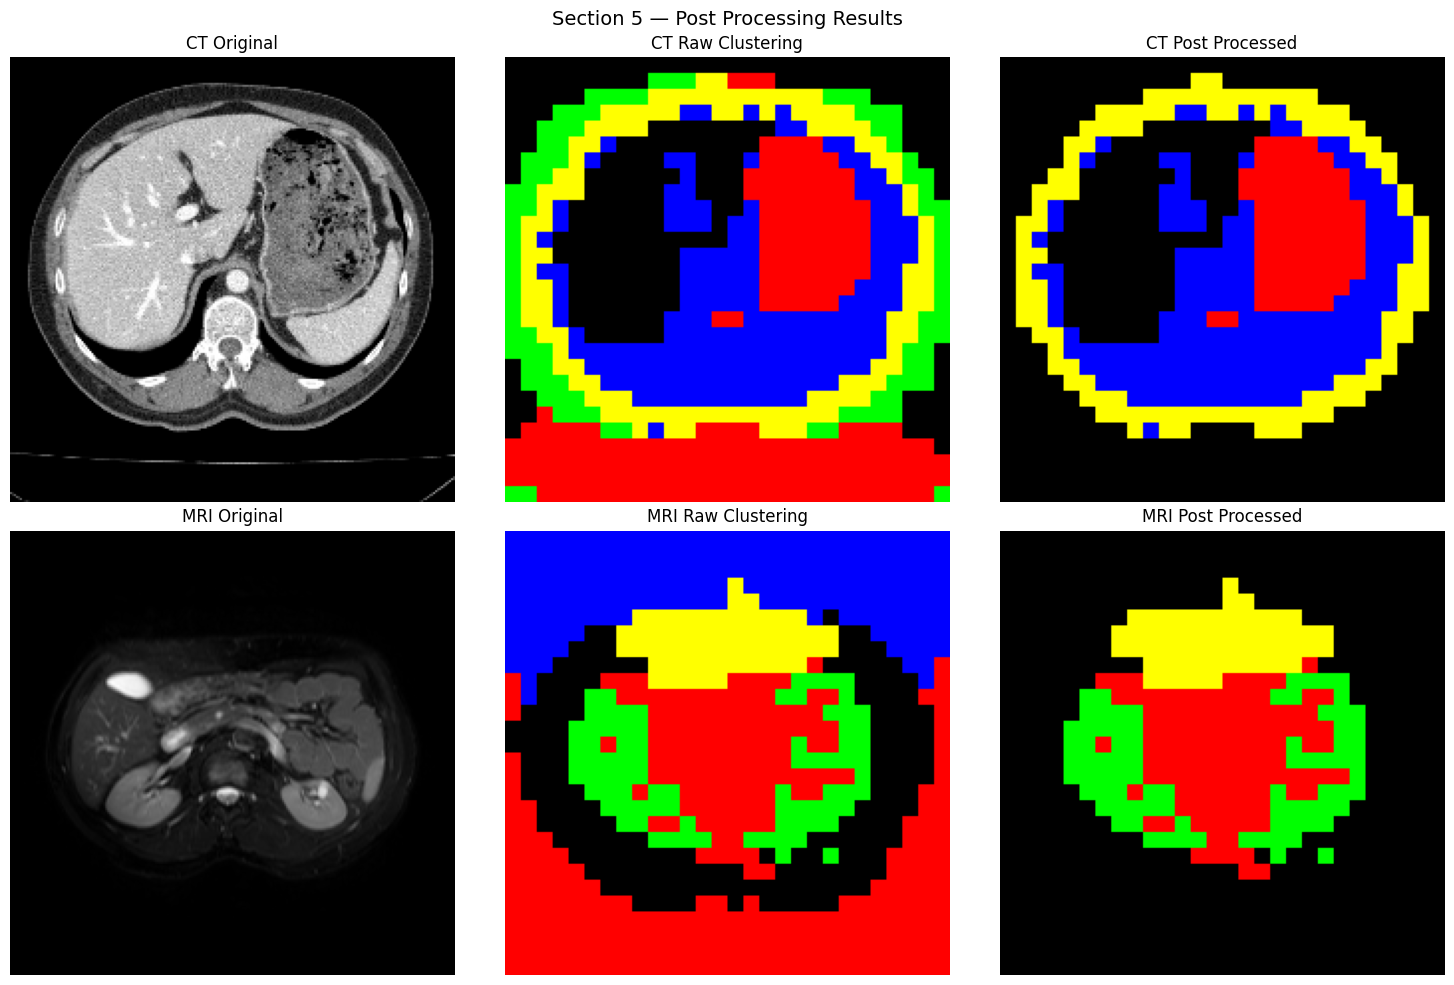

In [ ]:
# ── Apply post-processing ──
seg_ct_clean  = remove_background_strips(seg_ct,
                                          ct_processed,
                                          bg_threshold=0.02)
seg_ct_morph  = apply_morphological_ops(seg_ct_clean)
seg_ct_final  = remove_small_regions(seg_ct_morph)

seg_mri_clean = remove_background_strips(seg_mri,
                                          mri_processed,
                                          bg_threshold=0.02)
seg_mri_morph = apply_morphological_ops(seg_mri_clean)
seg_mri_final = remove_small_regions(seg_mri_morph)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(ct_processed)
axes[0,0].set_title('CT Original');          axes[0,0].axis('off')
axes[0,1].imshow(colorize_segmentation(seg_ct))
axes[0,1].set_title('CT Raw Clustering');    axes[0,1].axis('off')
axes[0,2].imshow(colorize_segmentation(seg_ct_final))
axes[0,2].set_title('CT Post Processed');    axes[0,2].axis('off')

axes[1,0].imshow(mri_processed)
axes[1,0].set_title('MRI Original');         axes[1,0].axis('off')
axes[1,1].imshow(colorize_segmentation(seg_mri))
axes[1,1].set_title('MRI Raw Clustering');   axes[1,1].axis('off')
axes[1,2].imshow(colorize_segmentation(seg_mri_final))
axes[1,2].set_title('MRI Post Processed');   axes[1,2].axis('off')

plt.suptitle('Section 5 — Post Processing Results',
             fontsize=14)
plt.tight_layout()
plt.savefig('postprocessing_results.png', dpi=150,
            bbox_inches='tight')
plt.show()

In [ ]:
def hungarian_matching(pred_seg, gt_mask):
    """
    Aligns predicted cluster IDs to GT organ labels
    using Hungarian algorithm.
    """
    gt_unique     = np.unique(gt_mask)
    gt_normalized = np.zeros_like(gt_mask)
    for i, val in enumerate(gt_unique):
        gt_normalized[gt_mask == val] = i

    pred_unique = np.unique(pred_seg)
    size        = max(len(pred_unique), len(gt_unique))
    cost_matrix = np.zeros((size, size))

    for i, p in enumerate(pred_unique):
        for j in range(len(gt_unique)):
            overlap           = np.sum(
                (pred_seg == p) & (gt_normalized == j))
            cost_matrix[i, j] = -overlap

    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    remapped         = np.zeros_like(pred_seg)
    for i, p in enumerate(pred_unique):
        if i < len(col_ind):
            remapped[pred_seg == p] = col_ind[i]

    return remapped, gt_normalized

def compute_metrics(pred_remapped, gt_normalized):
    """
    Computes Dice, IoU, Pixel Accuracy
    after Hungarian matching.
    """
    classes     = np.unique(gt_normalized)
    dice_scores = {}
    iou_scores  = {}

    for cls in classes:
        pred_cls     = (pred_remapped == cls)
        gt_cls       = (gt_normalized == cls)
        intersection = np.sum(pred_cls & gt_cls)
        union        = np.sum(pred_cls | gt_cls)
        pred_sum     = np.sum(pred_cls)
        gt_sum       = np.sum(gt_cls)

        dice = (2 * intersection) / (pred_sum + gt_sum) \
               if pred_sum + gt_sum > 0 else 1.0
        iou  = intersection / union if union > 0 else 1.0

        dice_scores[int(cls)] = round(dice, 4)
        iou_scores[int(cls)]  = round(iou,  4)

    pixel_acc = np.sum(
        pred_remapped == gt_normalized
    ) / gt_normalized.size

    return dice_scores, iou_scores, round(pixel_acc, 4)

print("✅ Evaluation functions loaded")

✅ Evaluation functions loaded


In [ ]:
CT_LABEL_NAMES  = {0: 'Background', 1: 'Liver'}
MRI_LABEL_NAMES = {
    0: 'Background',
    1: 'Liver',
    2: 'Right Kidney',
    3: 'Left Kidney',
    4: 'Spleen'
}

def evaluate_patients(modality='CT', n_patients=3):
    if modality == 'CT':
        patients = ct_patients[:n_patients]
        base_dir = CT_DIR
    else:
        patients = mri_patients[:n_patients]
        base_dir = MRI_DIR

    all_results   = []
    all_class_dice = {}
    all_class_iou  = {}

    for pid in patients:
        print(f"\n── Patient {pid} ({modality}) ──")

        if modality == 'CT':
            dicom_dir = os.path.join(base_dir, pid,
                                     'DICOM_anon')
            mask_dir  = os.path.join(base_dir, pid,
                                     'Ground')
        else:
            dicom_dir = os.path.join(base_dir, pid,
                                     'T2SPIR', 'DICOM_anon')
            mask_dir  = os.path.join(base_dir, pid,
                                     'T2SPIR', 'Ground')

        dcm_files  = sorted([f for f in os.listdir(dicom_dir)
                               if f.endswith('.dcm')])
        mask_files = sorted([f for f in os.listdir(mask_dir)
                               if f.endswith('.png')])

        if not mask_files:
            print(f"  No masks — skipping")
            continue

        total   = len(mask_files)
        indices = [int(total*0.3),
                   int(total*0.5),
                   int(total*0.7)]

        p_dice       = []
        p_iou        = []
        p_pacc       = []
        p_class_dice = {}
        p_class_iou  = {}

        for idx in indices:
            if idx >= min(len(dcm_files), len(mask_files)):
                continue
            try:
                pred, slc = full_pipeline(
                    os.path.join(dicom_dir, dcm_files[idx]),
                    modality=modality
                )
                gt = load_gt_mask(
                    os.path.join(mask_dir, mask_files[idx])
                )
                pred_r, gt_n = hungarian_matching(pred, gt)
                dice, iou, pacc = compute_metrics(
                    pred_r, gt_n)

                p_dice.append(np.mean(list(dice.values())))
                p_iou.append(np.mean(list(iou.values())))
                p_pacc.append(pacc)

                for cls in dice:
                    if cls not in p_class_dice:
                        p_class_dice[cls] = []
                        p_class_iou[cls]  = []
                    p_class_dice[cls].append(dice[cls])
                    p_class_iou[cls].append(iou[cls])

                print(f"  Slice {idx:2d} → "
                      f"Dice: {np.mean(list(dice.values())):.4f}  "
                      f"IoU:  {np.mean(list(iou.values())):.4f}  "
                      f"PixAcc: {pacc:.4f}")

            except Exception as e:
                print(f"  Slice {idx} error: {e}")

        if p_dice:
            all_results.append({
                'patient': pid,
                'dice'   : np.mean(p_dice),
                'iou'    : np.mean(p_iou),
                'pacc'   : np.mean(p_pacc)
            })
            for cls in p_class_dice:
                if cls not in all_class_dice:
                    all_class_dice[cls] = []
                    all_class_iou[cls]  = []
                all_class_dice[cls].append(
                    np.mean(p_class_dice[cls]))
                all_class_iou[cls].append(
                    np.mean(p_class_iou[cls]))

    # ── Patient Summary ──
    print("\n" + "=" * 55)
    print(f"{modality} RESULTS — {n_patients} Patients")
    print("=" * 55)
    print(f"{'Patient':<12} {'Dice':>10} "
          f"{'IoU':>10} {'PixAcc':>10}")
    print("-" * 55)
    for r in all_results:
        print(f"{r['patient']:<12} "
              f"{r['dice']:>10.4f} "
              f"{r['iou']:>10.4f} "
              f"{r['pacc']:>10.4f}")
    print("-" * 55)
    if all_results:
        print(f"{'Overall':<12} "
              f"{np.mean([r['dice'] for r in all_results]):>10.4f} "
              f"{np.mean([r['iou']  for r in all_results]):>10.4f} "
              f"{np.mean([r['pacc'] for r in all_results]):>10.4f}")
    print("=" * 55)

    # ── Per Class ──
    label_names = CT_LABEL_NAMES if modality == 'CT' \
                  else MRI_LABEL_NAMES
    print(f"\nPer-Class Breakdown — {modality}")
    print("=" * 55)
    print(f"{'Class':<15} {'Dice':>10} {'IoU':>10}")
    print("-" * 55)
    for cls, name in label_names.items():
        if cls in all_class_dice:
            print(f"{name:<15} "
                  f"{np.mean(all_class_dice[cls]):>10.4f} "
                  f"{np.mean(all_class_iou[cls]):>10.4f}")
    print("-" * 55)
    print(f"{'Mean':<15} "
          f"{np.mean([np.mean(v) for v in all_class_dice.values()]):>10.4f} "
          f"{np.mean([np.mean(v) for v in all_class_iou.values()]):>10.4f}")
    print("=" * 55)

    return all_results


# ── Run CT ──
ct_results  = evaluate_patients(modality='CT',  n_patients=3)


── Patient 1 (CT) ──
  PCA variance explained : 98.7%
  Slice 28 → Dice: 0.7598  IoU:  0.6184  PixAcc: 0.7480
  PCA variance explained : 98.7%
  Slice 48 → Dice: 0.3785  IoU:  0.2736  PixAcc: 0.5079
  PCA variance explained : 98.8%
  Slice 67 → Dice: 0.4903  IoU:  0.3315  PixAcc: 0.4537

── Patient 10 (CT) ──
  PCA variance explained : 98.6%
  Slice 33 → Dice: 0.4642  IoU:  0.3023  PixAcc: 0.3851
  PCA variance explained : 98.6%
  Slice 55 → Dice: 0.6511  IoU:  0.4827  PixAcc: 0.5132
  PCA variance explained : 98.7%
  Slice 77 → Dice: 0.4073  IoU:  0.2681  PixAcc: 0.4263

── Patient 14 (CT) ──
  PCA variance explained : 98.9%
  Slice 28 → Dice: 0.7696  IoU:  0.6257  PixAcc: 0.6268
  PCA variance explained : 99.1%
  Slice 47 → Dice: 0.5352  IoU:  0.3688  PixAcc: 0.4765
  PCA variance explained : 99.3%
  Slice 66 → Dice: 0.5071  IoU:  0.3801  PixAcc: 0.6289

CT RESULTS — 3 Patients
Patient            Dice        IoU     PixAcc
-------------------------------------------------------
1   

In [ ]:
# ── Run MRI ──
mri_results = evaluate_patients(modality='MRI', n_patients=3)


── Patient 1 (MRI) ──
  PCA variance explained : 99.3%
  Slice 10 → Dice: 0.9020  IoU:  0.8214  PixAcc: 0.8214
  PCA variance explained : 99.2%
  Slice 18 → Dice: 0.2357  IoU:  0.1829  PixAcc: 0.6898
  PCA variance explained : 99.2%
  Slice 25 → Dice: 0.2807  IoU:  0.2218  PixAcc: 0.7232

── Patient 10 (MRI) ──
  PCA variance explained : 99.7%
  Slice 10 → Dice: 0.3010  IoU:  0.2742  PixAcc: 0.8224
  PCA variance explained : 99.6%
  Slice 18 → Dice: 0.3347  IoU:  0.2529  PixAcc: 0.7312
  PCA variance explained : 99.6%
  Slice 25 → Dice: 0.4817  IoU:  0.3896  PixAcc: 0.7699

── Patient 13 (MRI) ──
  PCA variance explained : 99.4%
  Slice  9 → Dice: 0.3810  IoU:  0.3084  PixAcc: 0.7633
  PCA variance explained : 99.3%
  Slice 15 → Dice: 0.3865  IoU:  0.2885  PixAcc: 0.6360
  PCA variance explained : 99.3%
  Slice 21 → Dice: 0.5926  IoU:  0.5319  PixAcc: 0.8817

MRI RESULTS — 3 Patients
Patient            Dice        IoU     PixAcc
-------------------------------------------------------


In [ ]:
print("\n" + "=" * 55)
print("FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"{'Modality':<12} {'Dice':>10} "
      f"{'IoU':>10} {'PixAcc':>10}")
print("-" * 55)

ct_dice  = np.mean([r['dice'] for r in ct_results])
ct_iou   = np.mean([r['iou']  for r in ct_results])
ct_pacc  = np.mean([r['pacc'] for r in ct_results])

mri_dice = np.mean([r['dice'] for r in mri_results])
mri_iou  = np.mean([r['iou']  for r in mri_results])
mri_pacc = np.mean([r['pacc'] for r in mri_results])

print(f"{'CT':<12} {ct_dice*100:>9.2f}% "
      f"{ct_iou*100:>9.2f}% {ct_pacc*100:>9.2f}%")
print(f"{'MRI':<12} {mri_dice*100:>9.2f}% "
      f"{mri_iou*100:>9.2f}% {mri_pacc*100:>9.2f}%")
print("-" * 55)
print(f"{'Overall':<12} "
      f"{np.mean([ct_dice, mri_dice])*100:>9.2f}% "
      f"{np.mean([ct_iou,  mri_iou])*100:>9.2f}% "
      f"{np.mean([ct_pacc, mri_pacc])*100:>9.2f}%")
print("=" * 55)


FINAL RESULTS SUMMARY
Modality           Dice        IoU     PixAcc
-------------------------------------------------------
CT               55.14%     40.57%     52.96%
MRI              43.29%     36.35%     75.99%
-------------------------------------------------------
Overall          49.22%     38.46%     64.47%


  PCA variance explained : 98.7%
  PCA variance explained : 99.2%


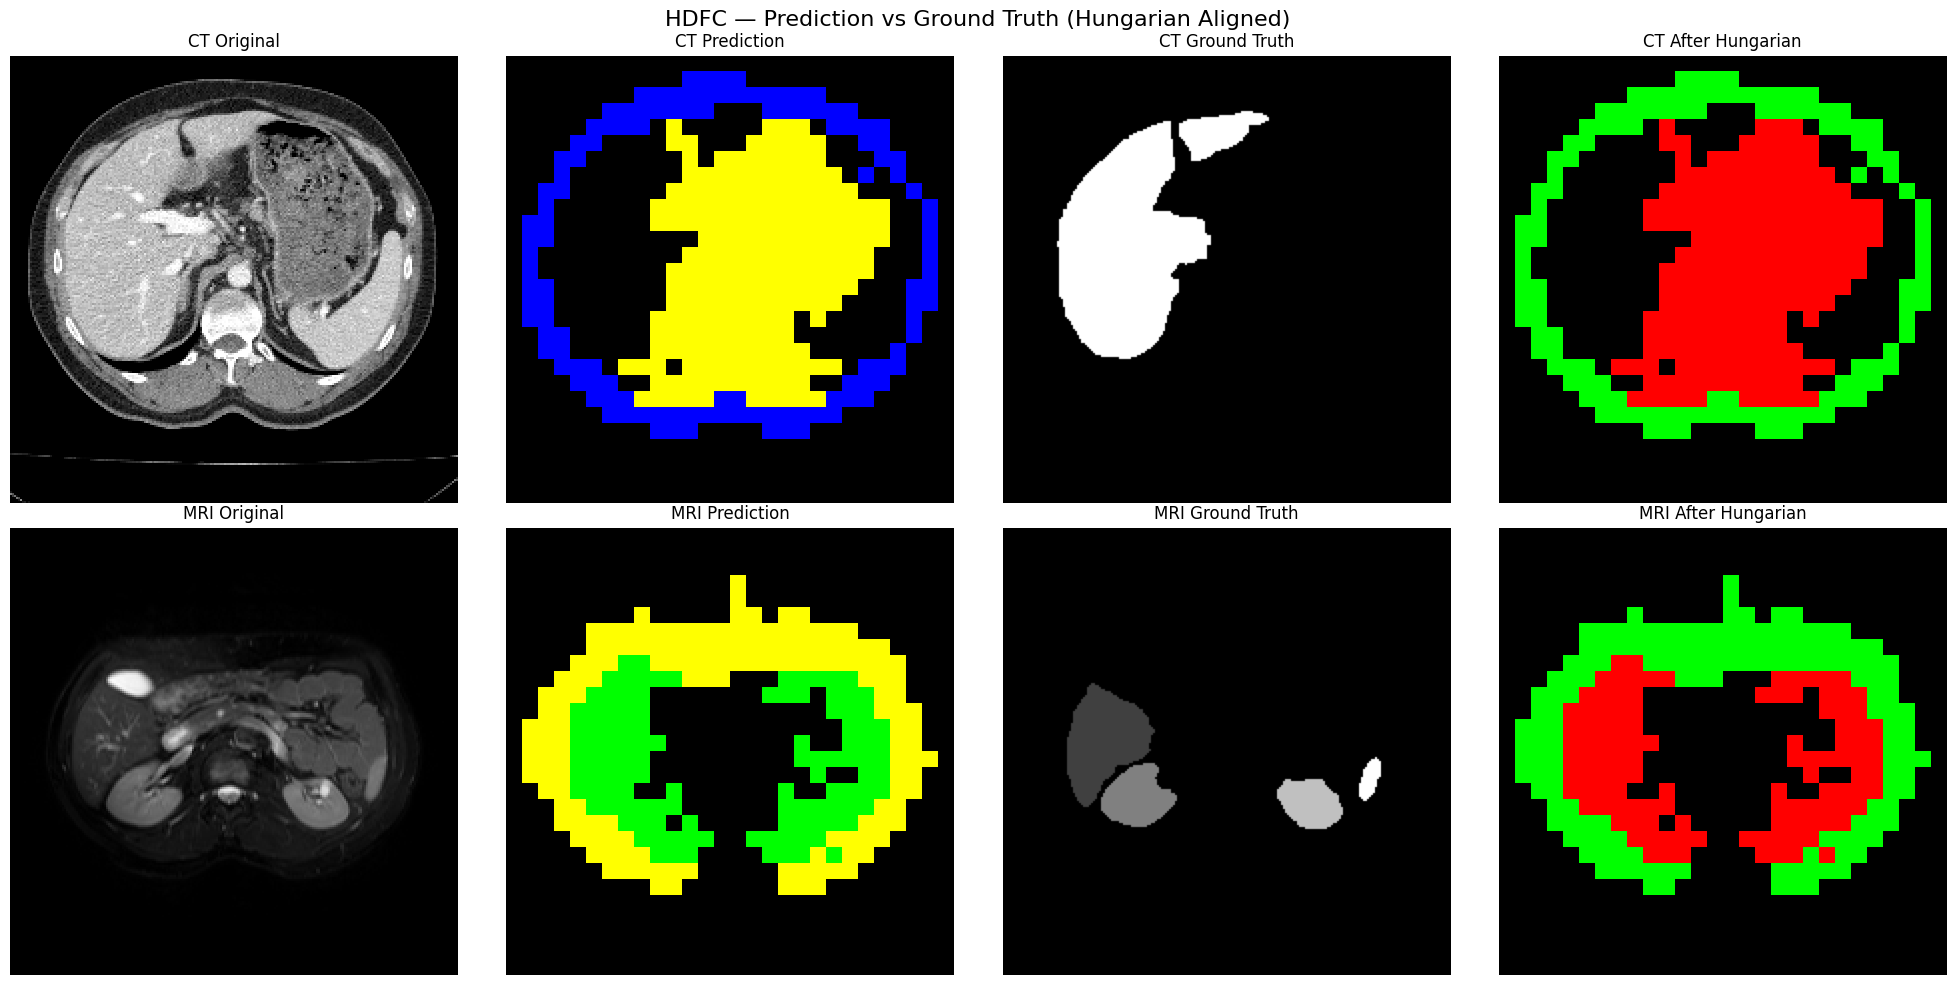

✅ Final figure saved as final_results.png


In [ ]:
# ── Load sample slices for visualization ──
ct_mask_dir   = os.path.join(CT_DIR,
                              ct_patients[0], 'Ground')
ct_mask_files = sorted([f for f in os.listdir(ct_mask_dir)
                          if f.endswith('.png')])
mid_ct        = len(ct_mask_files) // 2

pred_ct, ct_slc = full_pipeline(
    os.path.join(ct_dicom_dir, ct_files[mid_ct]),
    modality='CT'
)
gt_ct           = load_gt_mask(
    os.path.join(ct_mask_dir, ct_mask_files[mid_ct])
)
pred_r_ct, gt_n_ct = hungarian_matching(pred_ct, gt_ct)

mri_mask_dir   = os.path.join(MRI_DIR, mri_patients[0],
                               'T2SPIR', 'Ground')
mri_mask_files = sorted([f for f in os.listdir(mri_mask_dir)
                           if f.endswith('.png')])
mid_mri        = len(mri_mask_files) // 2

pred_mri, mri_slc = full_pipeline(
    os.path.join(mri_dicom_dir, mri_files[mid_mri]),
    modality='MRI'
)
gt_mri             = load_gt_mask(
    os.path.join(mri_mask_dir, mri_mask_files[mid_mri])
)
pred_r_mri, gt_n_mri = hungarian_matching(pred_mri, gt_mri)

# ── Plot ──
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

axes[0,0].imshow(ct_slc)
axes[0,0].set_title('CT Original');        axes[0,0].axis('off')
axes[0,1].imshow(CLUSTER_COLORS[pred_ct % 5])
axes[0,1].set_title('CT Prediction');      axes[0,1].axis('off')
axes[0,2].imshow(gt_ct, cmap='gray')
axes[0,2].set_title('CT Ground Truth');    axes[0,2].axis('off')
axes[0,3].imshow(CLUSTER_COLORS[pred_r_ct % 5])
axes[0,3].set_title('CT After Hungarian'); axes[0,3].axis('off')

axes[1,0].imshow(mri_slc)
axes[1,0].set_title('MRI Original');        axes[1,0].axis('off')
axes[1,1].imshow(CLUSTER_COLORS[pred_mri % 5])
axes[1,1].set_title('MRI Prediction');      axes[1,1].axis('off')
axes[1,2].imshow(gt_mri, cmap='gray')
axes[1,2].set_title('MRI Ground Truth');    axes[1,2].axis('off')
axes[1,3].imshow(CLUSTER_COLORS[pred_r_mri % 5])
axes[1,3].set_title('MRI After Hungarian'); axes[1,3].axis('off')

plt.suptitle(
    'HDFC — Prediction vs Ground Truth (Hungarian Aligned)',
    fontsize=16
)
plt.tight_layout()
plt.savefig('final_results.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Final figure saved as final_results.png")

In [ ]:
def calculate_miou(modality='CT', n_patients=3):
    """
    Calculates mean IoU (mIoU) across all patients and slices.
    mIoU = average IoU across all classes and all slices.
    """
    if modality == 'CT':
        patients = ct_patients[:n_patients]
        base_dir = CT_DIR
        label_names = {0: 'Background', 1: 'Liver'}
    else:
        patients = mri_patients[:n_patients]
        base_dir = MRI_DIR
        label_names = {
            0: 'Background',
            1: 'Liver',
            2: 'Right Kidney',
            3: 'Left Kidney',
            4: 'Spleen'
        }

    # Store IoU per class across all slices
    class_iou_all = {}

    for pid in patients:
        print(f"\n── Patient {pid} ({modality}) ──")

        if modality == 'CT':
            dicom_dir = os.path.join(base_dir, pid,
                                     'DICOM_anon')
            mask_dir  = os.path.join(base_dir, pid,
                                     'Ground')
        else:
            dicom_dir = os.path.join(base_dir, pid,
                                     'T2SPIR', 'DICOM_anon')
            mask_dir  = os.path.join(base_dir, pid,
                                     'T2SPIR', 'Ground')

        dcm_files  = sorted([f for f in os.listdir(dicom_dir)
                               if f.endswith('.dcm')])
        mask_files = sorted([f for f in os.listdir(mask_dir)
                               if f.endswith('.png')])

        if not mask_files:
            print(f"  No masks — skipping")
            continue

        total   = len(mask_files)
        indices = [int(total*0.3),
                   int(total*0.5),
                   int(total*0.7)]

        for idx in indices:
            if idx >= min(len(dcm_files),
                          len(mask_files)):
                continue
            try:
                pred, slc = full_pipeline(
                    os.path.join(dicom_dir, dcm_files[idx]),
                    modality=modality
                )
                gt = load_gt_mask(
                    os.path.join(mask_dir, mask_files[idx])
                )
                pred_r, gt_n = hungarian_matching(pred, gt)
                dice, iou, pacc = compute_metrics(
                    pred_r, gt_n)

                # Store per-class IoU
                for cls in iou:
                    if cls not in class_iou_all:
                        class_iou_all[cls] = []
                    class_iou_all[cls].append(iou[cls])

                print(f"  Slice {idx:2d} → "
                      f"mIoU: {np.mean(list(iou.values())):.4f}")

            except Exception as e:
                print(f"  Slice {idx} error: {e}")

    # ── Per Class IoU Table ──
    print("\n" + "=" * 50)
    print(f"mIoU RESULTS — {modality} "
          f"({n_patients} patients)")
    print("=" * 50)
    print(f"{'Class':<15} {'Mean IoU':>10} "
          f"{'Std':>9}") # Adjusted for % format
    print("-" * 50)

    class_means = []
    for cls in sorted(class_iou_all.keys()):
        name      = label_names.get(cls, f'Class {cls}')
        mean_iou  = np.mean(class_iou_all[cls])
        std_iou   = np.std(class_iou_all[cls])
        class_means.append(mean_iou)
        print(f"{name:<15} "
              f"{mean_iou*100:>9.2f}% " # Formatted as percentage
              f"{std_iou*100:>9.2f}%") # Formatted as percentage

    print("-" * 50)
    miou = np.mean(class_means)
    print(f"{('mIoU'):<15} {miou*100:>9.2f}%") # Formatted as percentage
    print("=" * 50)

    return miou, class_iou_all


# ── Run mIoU for CT ──
print("Calculating CT mIoU...")
ct_miou, ct_class_iou = calculate_miou(
    modality='CT', n_patients=3
)

# ── Run mIoU for MRI ──
print("\nCalculating MRI mIoU...")
mri_miou, mri_class_iou = calculate_miou(
    modality='MRI', n_patients=3
)

# ── Overall mIoU ──
print("\n" + "=" * 50)
print("FINAL mIoU SUMMARY")
print("=" * 50)
print(f"CT  mIoU     : {ct_miou:.4f}")
print(f"MRI mIoU     : {mri_miou:.4f}")
print(f"Overall mIoU : {np.mean([ct_miou, mri_miou]):.4f}")
print("=" * 50)

Calculating CT mIoU...

── Patient 1 (CT) ──
  PCA variance explained : 98.7%
  Slice 28 → mIoU: 0.6184
  PCA variance explained : 98.7%
  Slice 48 → mIoU: 0.2736
  PCA variance explained : 98.8%
  Slice 67 → mIoU: 0.3315

── Patient 10 (CT) ──
  PCA variance explained : 98.6%
  Slice 33 → mIoU: 0.3023
  PCA variance explained : 98.6%
  Slice 55 → mIoU: 0.4827
  PCA variance explained : 98.7%
  Slice 77 → mIoU: 0.2681

── Patient 14 (CT) ──
  PCA variance explained : 98.9%
  Slice 28 → mIoU: 0.6257
  PCA variance explained : 99.1%
  Slice 47 → mIoU: 0.3688
  PCA variance explained : 99.3%
  Slice 66 → mIoU: 0.3801

mIoU RESULTS — CT (3 patients)
Class             Mean IoU       Std
--------------------------------------------------
Background          49.68%     12.17%
Liver               31.45%     18.80%
--------------------------------------------------
mIoU                40.57%

Calculating MRI mIoU...

── Patient 1 (MRI) ──
  PCA variance explained : 99.3%
  Slice 10 → mIoU: 0.82

In [ ]:
import csv
import os

In [ ]:
def log_experiment(exp_name, epoch, dice, iou, miou, notes=""):
    file_exists = os.path.isfile("experiments.csv")

    with open("experiments.csv", mode="a", newline="") as file:
        writer = csv.writer(file)

        if not file_exists:
            writer.writerow(["experiment", "epoch", "dice", "iou", "miou", "notes"])

        writer.writerow([exp_name, epoch, dice, iou, miou, notes])

In [ ]:
log_experiment(
    exp_name="MRI_fix_v1",
    epoch=10,
    dice=0.52,
    iou=0.41,
    miou=0.40,
    notes="added normalization"
)